In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from numpy import percentile
import xarray as xr

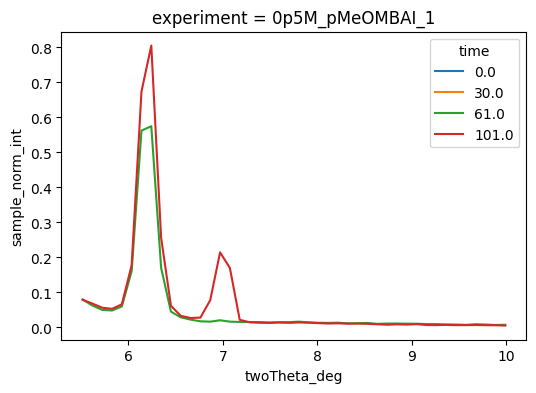

In [15]:
pdataset = xr.open_dataset(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\giwaxs_combined.nc")

pdataset = pdataset.swap_dims({"q_A^-1": "twoTheta_deg"})

sample_1 = pdataset.isel(experiment=3)

fig, ax = plt.subplots(figsize=(6,4))

sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 10)).sel(time=[0, 30, 60, 100], method='nearest').plot.line(x="twoTheta_deg", ax=ax)

Voigt Fit Parameters for peak at 6.24°:
  Amplitude: 0.212
  Center: 6.268°
  Sigma: 0.072
  Gamma: 0.026
  Slope: -0.037
  Offset: -0.000

Voigt Fit Parameters for peak at 7.08°:
  Amplitude: 0.041
  Center: 7.053°
  Sigma: 0.163
  Gamma: 0.000
  Slope: -0.024
  Offset: -0.006

Voigt Fit Parameters for peak at 11.66°:
  Amplitude: 0.019
  Center: 11.600°
  Sigma: 0.227
  Gamma: 0.014
  Slope: -0.000
  Offset: 0.001

Voigt Fit Parameters for peak at 13.34°:
  Amplitude: 0.106
  Center: 13.286°
  Sigma: 0.090
  Gamma: 0.134
  Slope: -0.000
  Offset: -0.004



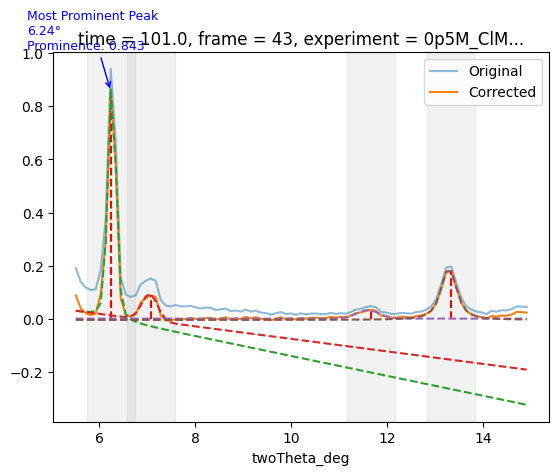

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
# Import functions from analysis library
from analysis import (
    baseline_correction,
    find_peaks_in_window,
    voigt_profile_func,
    voigt_fit
)

sample_1_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 15)).dropna('time').sel(time=100, method='nearest')

corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

# fig, ax = plt.subplots(figsize=(6,4))
sample_1_da.plot(label='Original', alpha=0.5)
corrected.plot(label='Corrected')
# calc_baseline.plot(label='Baseline', linestyle=':', alpha=0.7)
plt.legend()
# plt.ylim(None, 0.15)

peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.01
)

plt.vlines(peaks_x, ymin=0, ymax=peaks_intensities, color='red', linestyle='--', label='Detected Peaks')

# get the most prominent peak
if properties:
    prominences = [prop['prominences'] for prop in properties]
    max_prom_idx = np.argmax(prominences)
    peak_pos = peaks_x[max_prom_idx]
    peak_intensity = peaks_intensities[max_prom_idx]
    plt.annotate(
        f"Most Prominent Peak\n{peak_pos:.2f}°\nProminence: {prominences[max_prom_idx]:.3f}",
        xy=(peak_pos, max(0.2, peak_intensity)),
        xytext=(-60,30),
        textcoords='offset points',
        ha='left',
        fontsize=9,
        color='blue',
        arrowprops=dict(arrowstyle='->', color='blue')
    )

fitted_das = []
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0 
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", peak_pos=peak_pos, window_size=0.9, no_slope=no_slope)
        fitted_das.append(fitted_da)
    except Exception as e:
        print(f"Voigt fit failed for peak at {peak_pos:.2f}°: {e}")
        continue
    fitted_da.plot(label=f'Voigt Fit at {peak_pos:.2f}°', linestyle='--')
    # print every property as .3f
    amp, cen, sigma, gamma, slope, offset = popt
    print(
        f"Voigt Fit Parameters for peak at {peak_pos:.2f}°:\n"
        f"  Amplitude: {amp:.3f}\n"
        f"  Center: {cen:.3f}°\n"
        f"  Sigma: {sigma:.3f}\n"
        f"  Gamma: {gamma:.3f}\n"
        f"  Slope: {slope:.3f}\n"
        f"  Offset: {offset:.3f}\n"
    )
    plt.axvspan(peak_pos - 0.5, peak_pos + 0.5, color='gray', alpha=0.1)

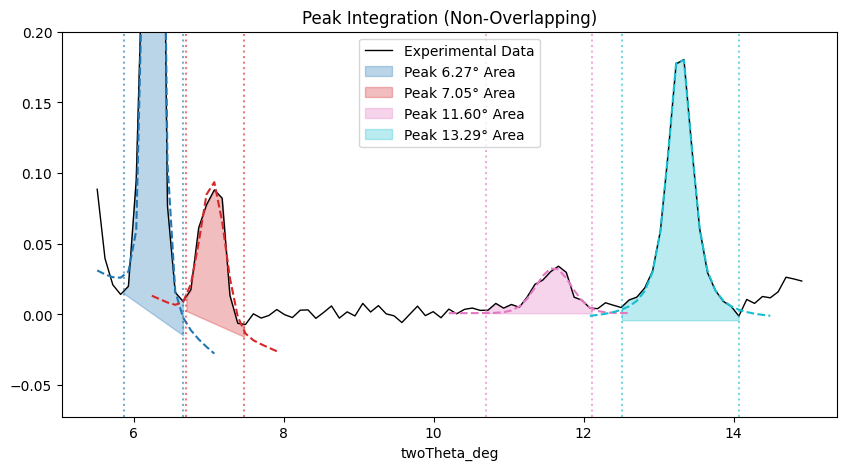

Peak Center  Area         Integration Range         Offset    
-----------------------------------------------------------------
6.268        0.20328      [5.871, 6.664]            -0.000    
7.053        0.03965      [6.703, 7.472]            -0.006    
11.600       0.02016      [10.697, 12.106]          0.001     
13.286       0.09481      [12.507, 14.066]          -0.004    


In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from analysis import calculate_peak_areas, voigt_fit, voigt_profile_func

# --- Usage (Re-run) ---

# 1. Collect fit results
collected_results = []
# print("Fitting peaks for area calculation...")
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", peak_pos=peak_pos, window_size=0.9, no_slope=no_slope)
        collected_results.append({'popt': popt, 'peak_pos': peak_pos})
    except RuntimeError:
        pass

# 2. Calculate areas (using 95% confidence)
areas_info = calculate_peak_areas(corrected, "twoTheta_deg", collected_results, confidence=0.99)

# 3. Visualization
plt.figure(figsize=(10, 5))
corrected.plot(label='Experimental Data', color='black', linewidth=1)

colors = plt.cm.tab10(np.linspace(0, 1, len(areas_info)))

for i, info in enumerate(areas_info):
    l, r = info['integration_range']
    cen = info['popt'][1]
    
    if len(info['popt']) == 6:
        offset = info['popt'][5] 
        slope = info['popt'][4]
    else:
        offset = 0
        slope = 0
        
    background_func = lambda x: slope * (x - cen) + offset

    color = colors[i]
    
    # Plot boundaries
    plt.axvline(l, linestyle=':', color=color, alpha=0.6)
    plt.axvline(r, linestyle=':', color=color, alpha=0.6)

    # Re-construct subset for plotting fill
    grid_x = np.linspace(l, r, 100) # simpler for plotting
    grid_y_data = corrected.interp({"twoTheta_deg": grid_x}).values
    subset = xr.DataArray(grid_y_data, coords={"twoTheta_deg": grid_x}, dims=["twoTheta_deg"])
    
    # Shade integration area (data - background)
    bg_vals = background_func(subset.twoTheta_deg)
    
    plt.fill_between(subset.twoTheta_deg, subset, bg_vals, 
                     where=(subset > bg_vals),
                     alpha=0.3, color=color, label=f'Peak {cen:.2f}° Area')
    
    # plot the fitted Voigt profile
    subset_x_fit = corrected.sel(**{"twoTheta_deg": slice(l-0.5, r+0.5)})["twoTheta_deg"].values
    if len(subset_x_fit) > 0:
        fitted_curve = voigt_profile_func(subset_x_fit, *info['popt'])
        plt.plot(subset_x_fit, fitted_curve, linestyle='--', color=color)

plt.legend()
plt.title("Peak Integration (Non-Overlapping)")
plt.ylim(None, 0.2)
plt.show()

# 4. Print Results
print(f"{'Peak Center':<12} {'Area':<12} {'Integration Range':<25} {'Offset':<10}")
print("-" * 65)
for info in areas_info:
    l, r = info['integration_range']
    if len(info['popt']) == 6:
        off = info['popt'][5]
    else:
        off = 0
    print(f"{info['popt'][1]:<12.3f} {info['area']:<12.5f} {f'[{l:.3f}, {r:.3f}]':<25} {off:<10.3f}")

In [7]:
sample_1 = pdataset.isel(experiment=2)

# 1. Select the time series data
time_series_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(0, 300))
times = time_series_da.time.values

sample_1_da = time_series_da.sel(time=1, method='nearest')

corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.005
)

print(f"Identified peaks at positions: {peaks_x}")

Identified peaks at positions: [10.82790171 13.23131532]


In [8]:
pdataset.experiment.values

array(['0p1M_ClMBAI_1', '0p5M_ClMBAI_1', '0p5M_MBAI_1', '0p5M_pMeOMBAI_1',
       '1p0M_ClMBAI_1', '1p0M_pMeOMBAI_1', '1p5M_ClMBAI_1',
       '1p5M_pMeOMBAI_1', 'insitu_0p5M_MeOMBAI_7',
       'insitu_1p0M_ClMBAI_6re', 'insitu_1p0M_MBAI_5',
       'insitu_1p0M_MeOMBAI_6'], dtype=object)

In [29]:
import analysis
import importlib
importlib.reload(analysis)
from analysis import process_time_series
import re

peaks_of_interest_dict = {
    "MBAI": [(6.9, 2), (13.3, 2)],
    "ClMBAI": [(6.1, 2), (13.3, 2)],
    "MeOMBAI": [(6.1, 2), (13.3, 2)]
}

result_dfs = {}

for experiment in pdataset.experiment.values:
    # 1. Select the time series data
    time_series_ds = pdataset.sel(experiment=experiment)
    time_series_da = time_series_ds["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(None, 300)).dropna(dim="time")

    # Defined peaks of interest: (center_position, window_size)
    for k, v in peaks_of_interest_dict.items():
        regexp = re.compile(f"M_{k}", re.IGNORECASE)
        if regexp.search(experiment):
            peaks_of_interest = v
            break
    
    if 'peaks_of_interest' not in locals():
        print(f"No peaks of interest defined for experiment: {experiment}. Skipping.")
        continue

    # 2. Run Analysis
    # Note: visualization of shifts is now saved to disk in time_series_results/experiment_1/visualized_step/
    df_evolution, warnings = process_time_series(
        time_series_da, 
        peaks_of_interest=peaks_of_interest, 
        sample_name=time_series_ds.experiment.values,
        shift_threshold=0.3, 
        perform_baseline_correction=False, 
        debug=True
    )

    # 3. Report Results
    if warnings:
        print("\n--- Significant Peak Shifts Detected ---")
        for w in warnings:
            # Limit printing if too many
            if warnings.index(w) < 10:
                print(w)
        if len(warnings) > 10:
            print(f"... and {len(warnings)-10} more.")

    result_dfs[experiment] = df_evolution
    print("\n--- Evolution DataFrame Head ---")
    print(df_evolution.head())




--- Evolution DataFrame Head ---
Peak Center  6.2       13.2  13.3  13.4
Time                                   
-5.0          NaN  0.241345   NaN   NaN
-3.0          NaN  0.245095   NaN   NaN
-1.0          NaN  0.215795   NaN   NaN
 1.0          NaN  0.188352   NaN   NaN
 3.0          NaN  0.188782   NaN   NaN

--- Evolution DataFrame Head ---
Peak Center  6.2   6.3       13.1      13.2  13.3
Time                                             
-9.0          NaN   NaN  0.228703       NaN   NaN
-7.0          NaN   NaN  0.228746       NaN   NaN
-5.0          NaN   NaN       NaN  0.237791   NaN
-3.0          NaN   NaN       NaN  0.241895   NaN
-1.0          NaN   NaN       NaN  0.244364   NaN

--- Significant Peak Shifts Detected ---
Time 263.0s: Peak 13.3° -> 12.990° (shift 0.310)

--- Evolution DataFrame Head ---
Peak Center  6.9   7.0   13.0      13.2      13.3
Time                                             
-5.0          NaN   NaN   NaN       NaN  0.122229
-3.0          NaN   NaN   N

Voigt fit failed for peak at 13.55: Optimal parameters not found: The maximum number of function evaluations is exceeded.



--- Significant Peak Shifts Detected ---
Time 61.0s: Peak 6.1° -> 6.507° (shift 0.407)
Time 63.0s: Peak 6.1° -> 6.510° (shift 0.410)
Time 65.0s: Peak 6.1° -> 6.524° (shift 0.424)
Time 67.0s: Peak 6.1° -> 6.529° (shift 0.429)
Time 69.0s: Peak 6.1° -> 6.531° (shift 0.431)
Time 71.0s: Peak 6.1° -> 6.530° (shift 0.430)
Time 73.0s: Peak 6.1° -> 6.531° (shift 0.431)
Time 75.0s: Peak 6.1° -> 6.531° (shift 0.431)
Time 85.0s: Peak 6.1° -> 6.532° (shift 0.432)
Time 87.0s: Peak 6.1° -> 6.537° (shift 0.437)
... and 95 more.

--- Evolution DataFrame Head ---
Peak Center  6.5   13.2      13.3      13.4  13.5  13.6
Time                                                   
-5.0          NaN   NaN  0.222976       NaN   NaN   NaN
-1.0          NaN   NaN  0.202956       NaN   NaN   NaN
 1.0          NaN   NaN       NaN  0.226378   NaN   NaN
 3.0          NaN   NaN  0.208565       NaN   NaN   NaN
 5.0          NaN   NaN       NaN  0.027334   NaN   NaN

--- Evolution DataFrame Head ---
Peak Center      6.0 

Voigt fit failed for peak at 13.44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for peak at 13.44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Voigt fit failed for pea


--- Significant Peak Shifts Detected ---
Time 67.0s: Peak 13.3° -> 13.698° (shift 0.398)
Time 87.0s: Peak 13.3° -> 13.618° (shift 0.318)
Time 119.0s: Peak 13.3° -> 13.941° (shift 0.641)
Time 201.0s: Peak 13.3° -> 13.941° (shift 0.641)
Time 217.0s: Peak 13.3° -> 13.726° (shift 0.426)
Time 237.0s: Peak 13.3° -> 13.785° (shift 0.485)
Time 241.0s: Peak 13.3° -> 13.843° (shift 0.543)
Time 251.0s: Peak 13.3° -> 13.812° (shift 0.512)
Time 261.0s: Peak 13.3° -> 13.941° (shift 0.641)
Time 271.0s: Peak 13.3° -> 13.891° (shift 0.591)
... and 1 more.

--- Evolution DataFrame Head ---
Peak Center      13.2      13.4  13.6  13.7  13.8  13.9
Time                                                   
-3.0         0.230680       NaN   NaN   NaN   NaN   NaN
-1.0         0.213921       NaN   NaN   NaN   NaN   NaN
 1.0         0.263220       NaN   NaN   NaN   NaN   NaN
 3.0         0.260829       NaN   NaN   NaN   NaN   NaN
 7.0              NaN  0.010938   NaN   NaN   NaN   NaN

--- Significant Peak Shifts

In [21]:
import pandas as pd

# Postprocessing: Merge peaks that are very close in position
def merge_close_peaks(df: pd.DataFrame, threshold: float = 0.2) -> pd.DataFrame:
    """
    Merge peaks in the DataFrame that are closer than the specified threshold using chaining logic.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with peak areas, columns are peak centers.
    threshold : float
        Maximum distance between *adjacent* peaks to consider for merging.
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with merged peaks.
    """
    if df.empty:
        return df

    peak_centers = sorted(df.columns.values)
    to_merge = []
    
    # Initialize first group
    current_group = [peak_centers[0]]
    
    for k in range(1, len(peak_centers)):
        center = peak_centers[k]
        prev_in_group = current_group[-1]
        
        # Check distance to the last peak in the current group (chaining)
        if (center - prev_in_group) < threshold:
            current_group.append(center)
        else:
            # Close current group and start new one
            to_merge.append(current_group)
            current_group = [center]
            
    # Append the last group
    if current_group:
        to_merge.append(current_group)
    
    # Create new DataFrame with merged peaks
    df_merged = pd.DataFrame(index=df.index)
    
    for group in to_merge:
        # Define new center name (mean of the group)
        new_center = np.round(np.mean(group), 3)
        
        if len(group) > 1:
            print(f"Merging peaks {group} -> {new_center}")
            # Sum areas, preserving NaNs if all are NaN
            df_merged[new_center] = df[group].sum(axis=1, min_count=1)
        else:
            # print(f"Keeping peak at {group[0]} as is.")
            df_merged[new_center] = df[group[0]]
    
    # Sort columns for cleaner look
    df_merged = df_merged.sort_index(axis=1)
    
    return df_merged

merged_dfs = {}

for experiment, df_evolution in result_dfs.items():
    print(f"\n--- Merging Close Peaks for Experiment: {experiment} ---")
    df_final = merge_close_peaks(df_evolution, threshold=0.2)
    print("Merged DataFrame Columns:", df_final.columns.values)
    df_final.head()
    merged_dfs[experiment] = df_final




--- Merging Close Peaks for Experiment: 0p1M_ClMBAI_1 ---
Merging peaks [np.float64(13.2), np.float64(13.3), np.float64(13.4)] -> 13.3
Merged DataFrame Columns: [ 6.2 13.3]

--- Merging Close Peaks for Experiment: 0p5M_ClMBAI_1 ---
Merging peaks [np.float64(6.2), np.float64(6.3)] -> 6.25
Merging peaks [np.float64(13.1), np.float64(13.2), np.float64(13.3)] -> 13.2
Merged DataFrame Columns: [ 6.25 13.2 ]

--- Merging Close Peaks for Experiment: 0p5M_MBAI_1 ---
Merging peaks [np.float64(6.9), np.float64(7.0)] -> 6.95
Merging peaks [np.float64(13.0), np.float64(13.2), np.float64(13.3)] -> 13.167
Merged DataFrame Columns: [ 6.95  13.167]

--- Merging Close Peaks for Experiment: 0p5M_pMeOMBAI_1 ---
Merging peaks [np.float64(13.2), np.float64(13.3), np.float64(13.4)] -> 13.3
Merged DataFrame Columns: [ 6.2 13.3]

--- Merging Close Peaks for Experiment: 1p0M_ClMBAI_1 ---
Merging peaks [np.float64(13.2), np.float64(13.3), np.float64(13.4), np.float64(13.5), np.float64(13.6)] -> 13.4
Merged Dat

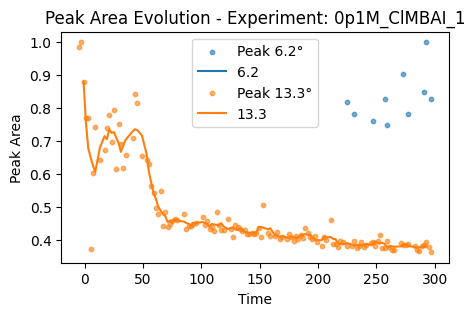

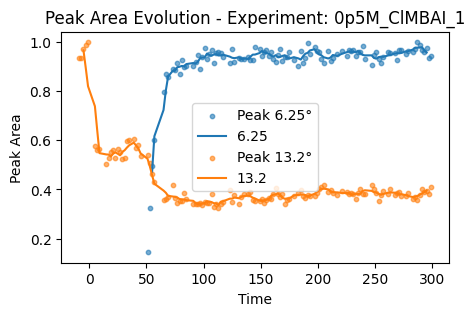

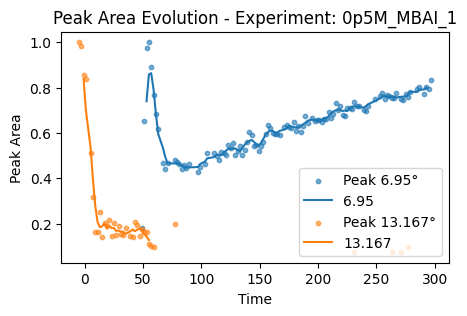

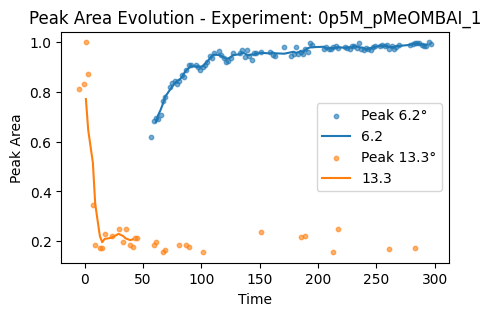

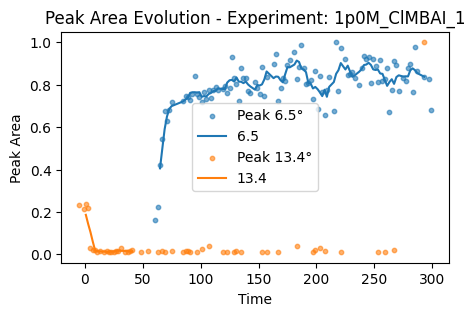

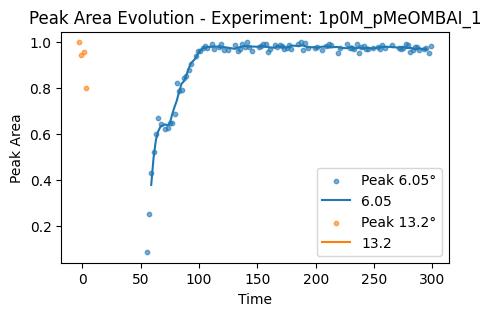

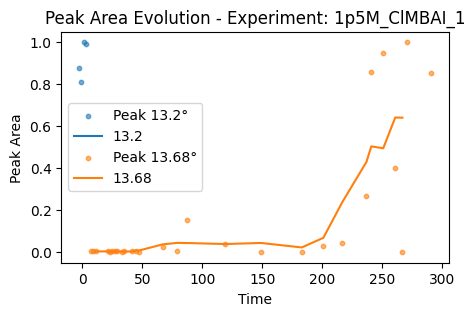

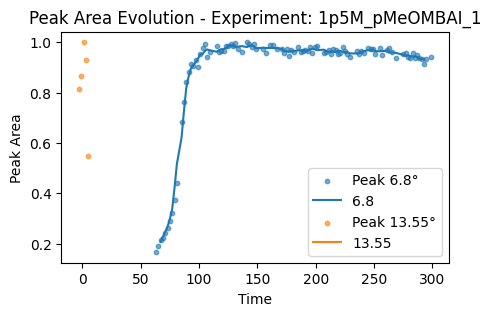

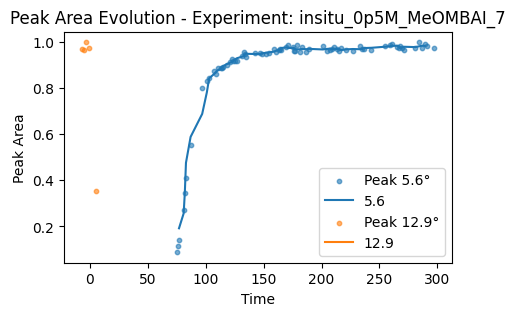

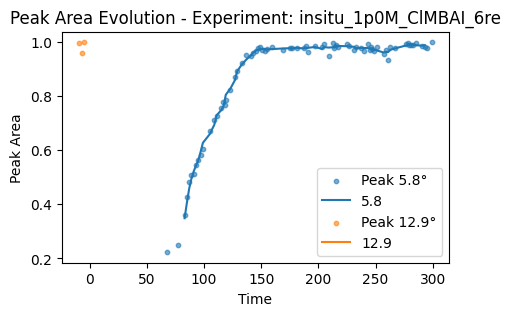

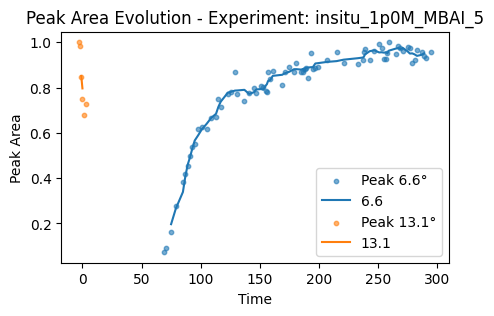

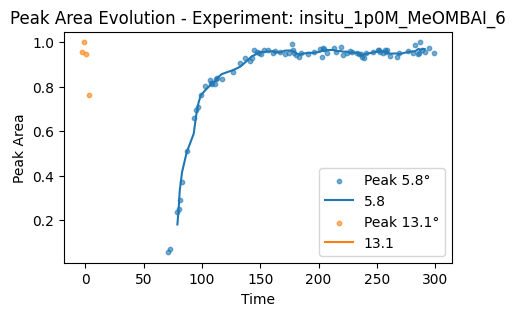

In [28]:
# plot merged results for each experiment
for experiment, df_final in merged_dfs.items():
    plt.figure(figsize=(5, 3))
    for peak_center in df_final.columns:
        # peak-wise normalize for better visualization
        df_final[peak_center] = df_final[peak_center] / df_final[peak_center].max()
        plt.scatter(df_final.index, df_final[peak_center], label=f'Peak {peak_center}°', alpha=0.6, s=10)
        # gaussian smoothing for better visualization, no label
        df_final[peak_center].rolling(window=5, center=True).mean().plot()

    
    plt.title(f'Peak Area Evolution - Experiment: {experiment}')
    plt.xlabel('Time')
    plt.ylabel('Peak Area')
    plt.legend()
    # plt.grid(True)
    plt.show()

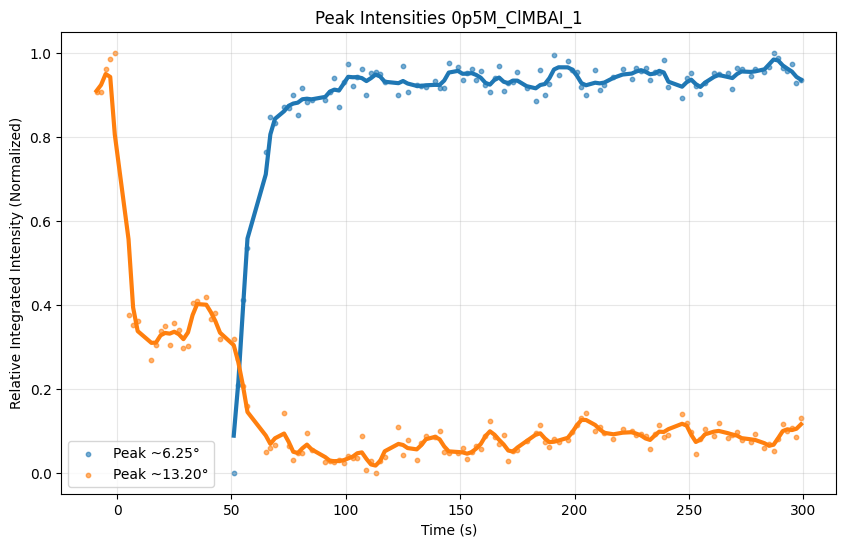

In [13]:


# 2. Plotting Normalized Time Series
plt.figure(figsize=(10, 6))

for peak_pos in df_final.columns:
    # Get the series for this peak
    peak_series = df_final[peak_pos]
    
    # Remove NaNs before plotting
    clean_series = peak_series.dropna()
    
    if not clean_series.empty:
        # Normalize to max intensity
        max_val = clean_series.max()
        min_val = clean_series.min()
        if max_val > 0:
            norm_series = (clean_series-min_val) / (max_val-min_val)
            label_str = f"Peak ~{peak_pos:.2f}°"
            plt.scatter(norm_series.index, norm_series.values, label=label_str, s=10, alpha=0.6)
            # plot gaussian smoothed line
            from scipy.ndimage import gaussian_filter1d
            smoothed = gaussian_filter1d(norm_series.values, sigma=1)
            plt.plot(norm_series.index, smoothed, linewidth=3)
    
plt.xlabel("Time (s)")
plt.ylabel("Relative Integrated Intensity (Normalized)")
plt.title(f"Peak Intensities {sample_1.experiment.values}",)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

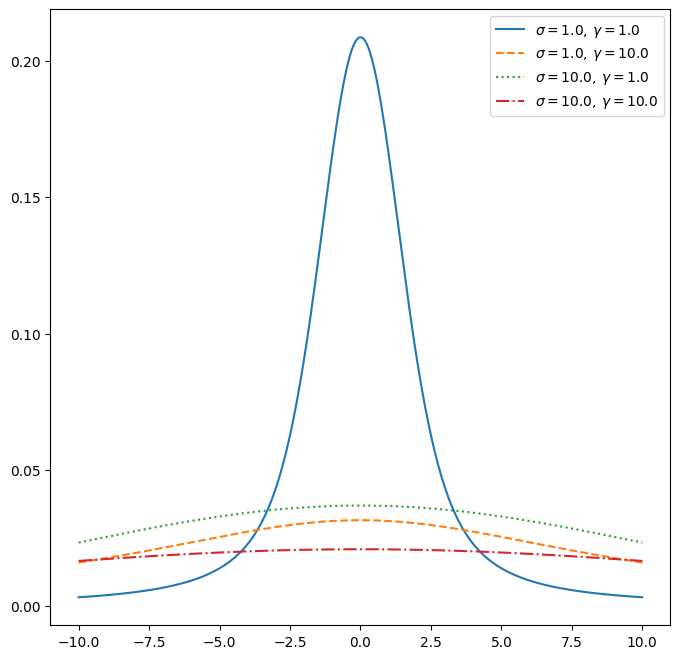

In [179]:
from scipy.special import voigt_profile
import numpy as np
import matplotlib.pyplot as plt
voigt_profile(2, 1., 1.)

fig, ax = plt.subplots(figsize=(8, 8))
x = np.linspace(-10, 10, 500)
parameters_list = [(1., 1., "solid"), (1., 10., "dashed"),
                   (10., 1., "dotted"), (10., 10., "dashdot")]
for params in parameters_list:
    sigma, gamma, linestyle = params
    voigt = voigt_profile(x, sigma, gamma)
    ax.plot(x, voigt, label=rf"$\sigma={sigma},\, \gamma={gamma}$",
            ls=linestyle)
ax.legend()
plt.show()